Partie 1 : Données - Preprocessing et Nettoyage

Étape 1 : Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Réglage des options
sns.set(style="whitegrid")

Étape 2 : Chargement des jeux de données

In [2]:
# Chargement des deux fichiers
math_df = pd.read_csv("../student-mat.csv", sep=';')
port_df = pd.read_csv("../student-por.csv", sep=';')

print(f"Math dataset: {math_df.shape}")
print(f"Portuguese dataset: {port_df.shape}")

math_df.head()

Math dataset: (395, 33)
Portuguese dataset: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Étape 3 : Fusion des deux datasets

In [3]:
common_cols = [
    'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'nursery', 'internet'
]

merged_df = pd.merge(
    math_df, port_df,
    on=common_cols,
    how='inner',
    suffixes=('_math', '_por')
)

print("Dimensions après fusion :", merged_df.shape)
merged_df.head()
print(merged_df.columns)


Dimensions après fusion : (382, 53)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian_math', 'traveltime_math',
       'studytime_math', 'failures_math', 'schoolsup_math', 'famsup_math',
       'paid_math', 'activities_math', 'nursery', 'higher_math', 'internet',
       'romantic_math', 'famrel_math', 'freetime_math', 'goout_math',
       'Dalc_math', 'Walc_math', 'health_math', 'absences_math', 'G1_math',
       'G2_math', 'G3_math', 'guardian_por', 'traveltime_por', 'studytime_por',
       'failures_por', 'schoolsup_por', 'famsup_por', 'paid_por',
       'activities_por', 'higher_por', 'romantic_por', 'famrel_por',
       'freetime_por', 'goout_por', 'Dalc_por', 'Walc_por', 'health_por',
       'absences_por', 'G1_por', 'G2_por', 'G3_por'],
      dtype='object')


Étape 4 : Nettoyage

In [4]:
# Vérification des valeurs manquantes
print(merged_df.isnull().sum())


school             0
sex                0
age                0
address            0
famsize            0
Pstatus            0
Medu               0
Fedu               0
Mjob               0
Fjob               0
reason             0
guardian_math      0
traveltime_math    0
studytime_math     0
failures_math      0
schoolsup_math     0
famsup_math        0
paid_math          0
activities_math    0
nursery            0
higher_math        0
internet           0
romantic_math      0
famrel_math        0
freetime_math      0
goout_math         0
Dalc_math          0
Walc_math          0
health_math        0
absences_math      0
G1_math            0
G2_math            0
G3_math            0
guardian_por       0
traveltime_por     0
studytime_por      0
failures_por       0
schoolsup_por      0
famsup_por         0
paid_por           0
activities_por     0
higher_por         0
romantic_por       0
famrel_por         0
freetime_por       0
goout_por          0
Dalc_por           0
Walc_por     

Étape 5 : Verification des Outliers

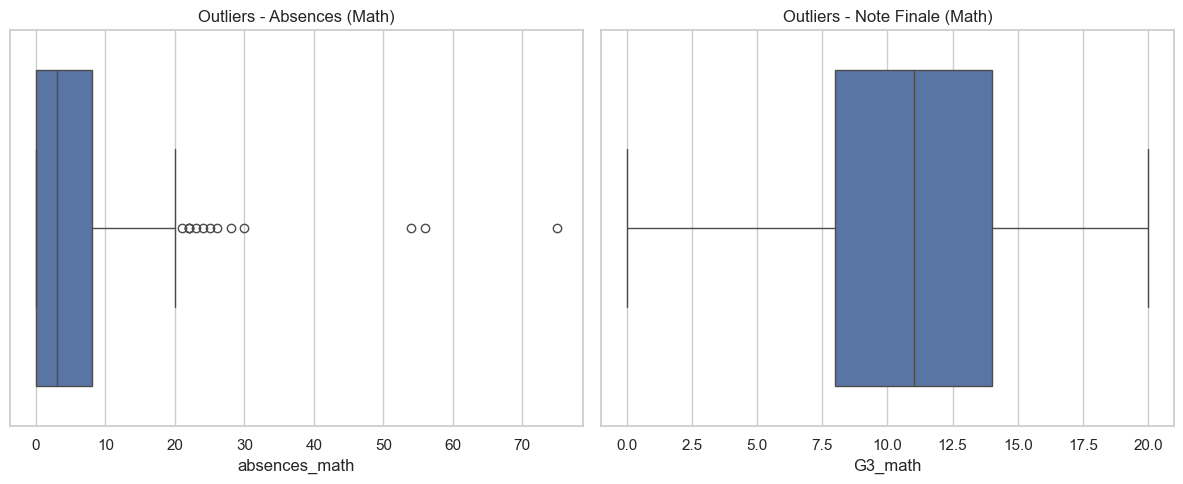

Outliers - Absences (Math) :
     absences_math
40              25
74              54
104             26
184             56
199             24
206             28
217             22
262             21
278             75
279             22
280             22
283             30
313             23

Outliers - Note Finale (Math) :
Empty DataFrame
Columns: [G3_math]
Index: []


In [5]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers[[column]]

# Affichage graphique avec boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=merged_df['absences_math'])
plt.title('Outliers - Absences (Math)')

plt.subplot(1, 2, 2)
sns.boxplot(x=merged_df['G3_math'])
plt.title('Outliers - Note Finale (Math)')

plt.tight_layout()
plt.show()

# Affichage des résultats numériques
print("Outliers - Absences (Math) :")
print(detect_outliers_iqr(merged_df, 'absences_math'))

print("\nOutliers - Note Finale (Math) :")
print(detect_outliers_iqr(merged_df, 'G3_math'))

Étape 6 : Suppression des doublons

In [6]:
# Avant suppression
print("Taille avant suppression des doublons :", merged_df.shape)

# Suppression des doublons
n_doublons = merged_df.drop_duplicates(inplace=True)
print(f"Nombre de doublons détectés et supprimés : {n_doublons}")

# Après suppression
print("Taille après suppression des doublons :", merged_df.shape)


Taille avant suppression des doublons : (382, 53)
Nombre de doublons détectés et supprimés : None
Taille après suppression des doublons : (382, 53)


Partie 2 : Transformation des données

Étape 1 : Features Engineering

In [ ]:
# Moyenne des notes en math
merged_df["grade_avg"] = merged_df[['G1_math', 'G2_math', 'G3_math']].mean(axis=1)

# Moyenne consommation alcool (semaine + week-end)
merged_df["alcohol_avg"] = merged_df[['Dalc_math', 'Walc_math']].mean(axis=1)

print("=== Statistiques descriptives de 'grade_avg' et 'alcohol_avg' ===")
print(merged_df[["grade_avg", "alcohol_avg"]].describe())

# Création d'une variable binaire "abuse_alcohol" : abus si moyenne > 3 (échelle 1 à 5)
merged_df["abuse_alcohol"] = merged_df["alcohol_avg"] > 3

# Création d'une variable binaire "success" : réussite si grade >= 10
merged_df["success"] = merged_df["grade_avg"] >= 10

print("\n=== Répartition de la variable 'abuse_alcohol' ===")
print(merged_df["abuse_alcohol"].value_counts())

print("\n=== Répartition de la variable 'success' ===")
print(merged_df["success"].value_counts())


=== Statistiques descriptives de 'grade_avg' et 'alcohol_avg' ===
        grade_avg  alcohol_avg
count  382.000000   382.000000
mean    10.653578     1.876963
std      3.766609     0.987743
min      1.333333     1.000000
25%      8.333333     1.000000
50%     10.666667     1.500000
75%     13.333333     2.500000
max     19.333333     5.000000

=== Répartition de la variable 'abuse_alcohol' ===
abuse_alcohol
False    344
True      38
Name: count, dtype: int64

=== Répartition de la variable 'success' ===
success
True     219
False    163
Name: count, dtype: int64


Étape 2 : Statistiques descriptives des variables numériques clés

In [8]:
# Statistiques des variables sensibles aux outliers
merged_df[["absences_math", "G3_math", "absences_por", "G3_por"]].describe()

,absences_math,G3_math,absences_por,G3_por
count,382.000000,382.000000,382.000000,382.000000
mean,5.319372,10.387435,3.672775,12.515707
std,7.625251,4.687242,4.905965,2.945438
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,8.000000,0.000000,11.000000
50%,3.000000,11.000000,2.000000,13.000000
75%,8.000000,14.000000,6.000000,14.000000
max,75.000000,20.000000,32.000000,19.000000


Étape 3 : Encodage des variables catégorielles

In [9]:
# Encodage des variables catégorielles
df_encoded = pd.get_dummies(merged_df, drop_first=True)
df_encoded.describe()

# Vérification
print("Forme du dataframe encodé :", df_encoded.shape)

Forme du dataframe encodé : (382, 67)


Étape 4 : Réduction de dimensionnalité (PCA)

Shape après normalisation : (382, 67)
Variance expliquée par chaque composante : [0.1224704  0.08024546]
Variance expliquée cumulée (2 composantes) : 0.20271586259864738


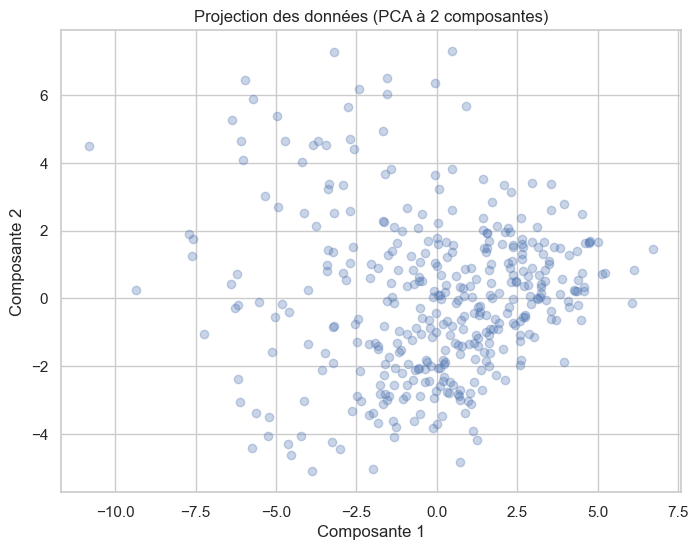

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Normalisation
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

# PCA à 2 composantes
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

print("Shape après normalisation :", df_scaled.shape)

# Variance expliquée par les composantes principales
explained_variance = pca.explained_variance_ratio_
print("Variance expliquée par chaque composante :", explained_variance)
print("Variance expliquée cumulée (2 composantes) :", explained_variance.sum())

# Visualisation
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3)
plt.title("Projection des données (PCA à 2 composantes)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.show()


Étape 5 : Sauvegarde / aperçu du jeu nettoyé

In [11]:
merged_df.head()
merged_df.to_csv("./merged_cleaned.csv", index=False)

Partie 3 : Visualisation et comparaisons

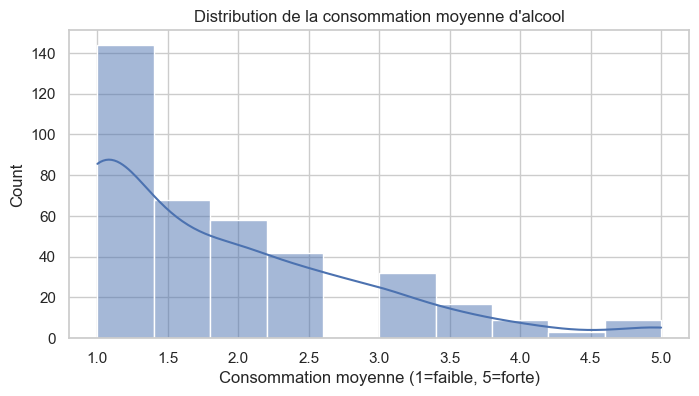

=== Statistiques de 'alcohol_avg' ===
count    382.000000
mean       1.876963
std        0.987743
min        1.000000
25%        1.000000
50%        1.500000
75%        2.500000
max        5.000000
Name: alcohol_avg, dtype: float64

Distribution des niveaux de consommation d'alcool moyenne :
alcohol_avg
1.0    144
1.5     68
2.0     58
2.5     42
3.0     32
3.5     17
4.0      9
4.5      3
5.0      9
Name: count, dtype: int64


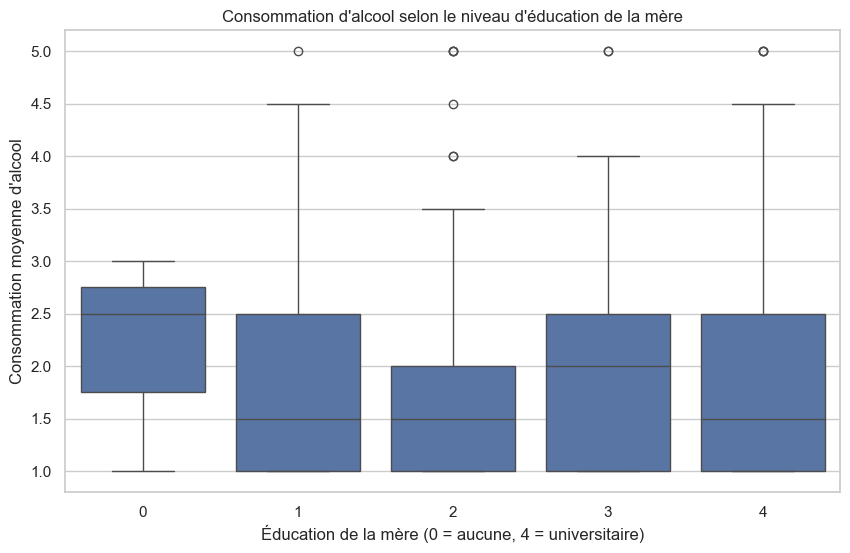


=== Moyenne de consommation d'alcool par niveau d'éducation de la mère (Medu) ===
Medu
0    2.17
1    1.92
2    1.73
3    2.02
4    1.86
Name: alcohol_avg, dtype: float64


In [12]:
# Histogramme de la consommation moyenne d'alcool
plt.figure(figsize=(8,4))
sns.histplot(merged_df["alcohol_avg"], kde=True)
plt.title("Distribution de la consommation moyenne d'alcool")
plt.xlabel("Consommation moyenne (1=faible, 5=forte)")
plt.show()

# Affichage numérique : statistiques de la variable alcohol_avg
print("=== Statistiques de 'alcohol_avg' ===")
print(merged_df["alcohol_avg"].describe())
print("\nDistribution des niveaux de consommation d'alcool moyenne :")
print(merged_df["alcohol_avg"].value_counts().sort_index())

# Boxplot : consommation d'alcool selon l'éducation de la mère
plt.figure(figsize=(10,6))
sns.boxplot(x="Medu", y="alcohol_avg", data=merged_df)
plt.title("Consommation d'alcool selon le niveau d'éducation de la mère")
plt.xlabel("Éducation de la mère (0 = aucune, 4 = universitaire)")
plt.ylabel("Consommation moyenne d'alcool")
plt.show()

# Affichage numérique : moyenne de consommation par niveau d'éducation de la mère
print("\n=== Moyenne de consommation d'alcool par niveau d'éducation de la mère (Medu) ===")
print(merged_df.groupby("Medu")["alcohol_avg"].mean().round(2))